# Online Retailer Business Problem

## Objective
To analyze the online retail data to uncover insights about customer behavior and purchasing patterns. The goal is to identify trends and opportunities for business growth.


## Dataset Overview
The dataset contains transactions from an online retailer based in the UK, including details such as invoice number, stock code, description, quantity, invoice date, price, customer ID, and country.


In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set(style='whitegrid')


In [3]:
data = pd.read_csv('online_retail.csv')

data.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,01-12-2009 07:45,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,01-12-2009 07:45,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,01-12-2009 07:45,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,01-12-2009 07:45,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,01-12-2009 07:45,1.25,13085.0,United Kingdom


In [4]:
print(data.columns)

print(data.shape)

data.info()

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object')
(317307, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 317307 entries, 0 to 317306
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      317307 non-null  object 
 1   StockCode    317307 non-null  object 
 2   Description  315108 non-null  object 
 3   Quantity     317307 non-null  int64  
 4   InvoiceDate  317307 non-null  object 
 5   Price        317307 non-null  float64
 6   Customer ID  250408 non-null  float64
 7   Country      317307 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 19.4+ MB


## Data Cleaning
- Remove missing values
- Filter out canceled transactions
- Convert types if necessary


In [6]:

# Remove rows with missing values

data = data.dropna()

# Remove canceled transactions (those with InvoiceNo starting with 'C')

data = data[~data['Invoice'].astype(str).str.startswith('C')]

# Convert InvoiceDate to datetime

data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'], format='%d-%m-%Y %H:%M')

# Preview cleaned data
data.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


## Exploratory Data Analysis (EDA)
Explore top-selling products, customer purchase behavior, and time-based trends.


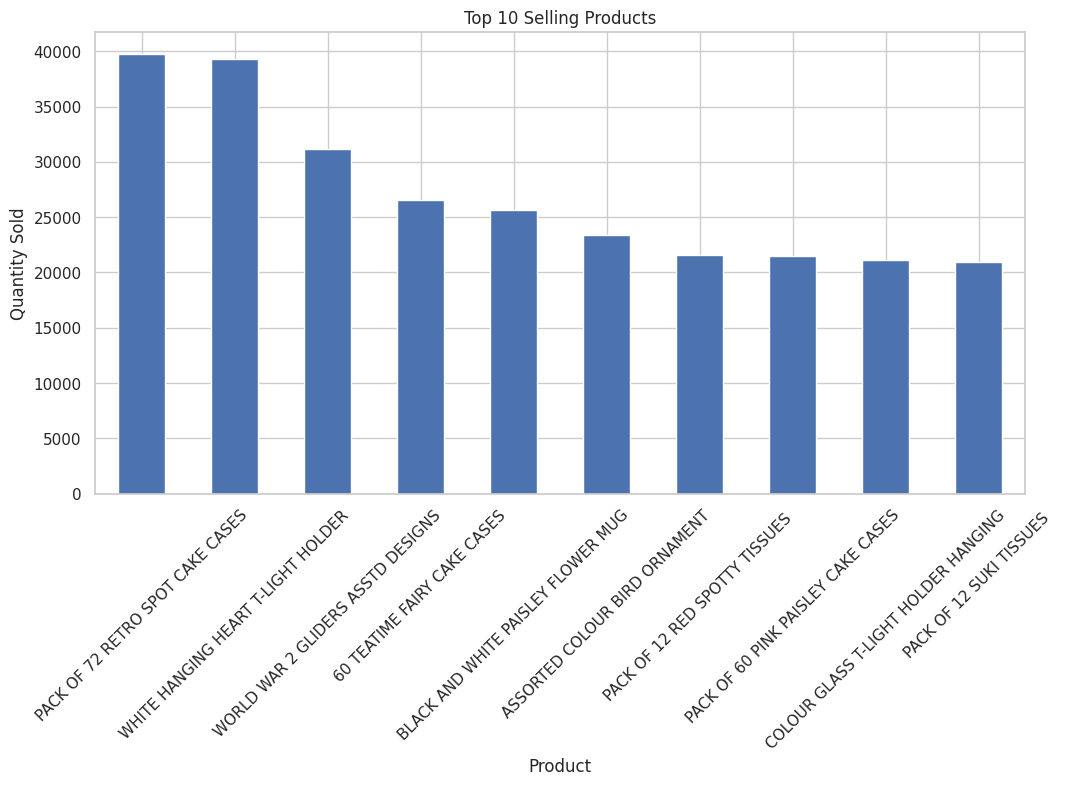

In [7]:
# Top 10 selling products

top_products = data.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))

top_products.plot(kind='bar')

plt.title('Top 10 Selling Products')

plt.xlabel('Product')

plt.ylabel('Quantity Sold')

plt.xticks(rotation=45)

plt.show()

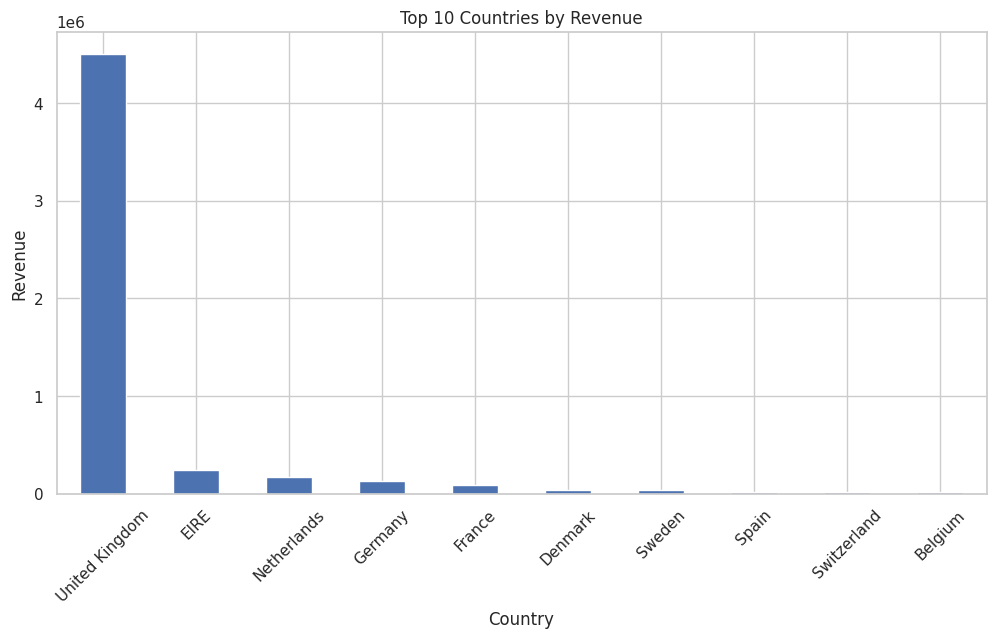

In [8]:
# Create Revenue column

data['Revenue'] = data['Quantity'] * data['Price']

# Revenue per country
country_revenue = data.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))

country_revenue.plot(kind='bar')

plt.title('Top 10 Countries by Revenue')

plt.xlabel('Country')

plt.ylabel('Revenue')

plt.xticks(rotation=45)

plt.show()

## Customer Segmentation Preparation
Prepare RFM (Recency, Frequency, Monetary) analysis to understand customer segments.


In [9]:
# Snapshot date

snapshot_date = data['InvoiceDate'].max() + pd.Timedelta(days=1)

# Create RFM table

rfm = data.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'Invoice': 'nunique',
    'Revenue': 'sum'
})

# Rename columns

rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'Invoice': 'Frequency',
    'Revenue': 'Monetary'
}, inplace=True)

# Preview RFM table

rfm.head()


,Recency,Frequency,Monetary
Customer ID,,,
12346.0,58,11,372.86
12349.0,100,2,1268.52
12355.0,97,1,488.21
12358.0,80,2,1697.93
12359.0,65,5,2012.03


Conclusion

This project analyzed retail transaction data using Python for data cleaning, exploratory analysis, and customer segmentation preparation.

The dataset was cleaned by removing missing values and canceled transactions, and date columns were converted into proper datetime format.

EDA identified top-selling products and the countries generating the highest revenue. Revenue analysis highlighted key markets contributing most to overall sales performance.

An RFM (Recency, Frequency, Monetary) table was also created to support customer segmentation and better understand purchasing behavior.

Overall, this project demonstrated practical retail analytics techniques including transaction analysis, revenue analysis, and customer segmentation preparation using Python.